# 🛰️ LiDAR & Copernicus DEM Processing Workflow

This notebook demonstrates a full workflow to acquire, process, and compare high-resolution elevation datasets over a selected region of interest (ROI).

## ✅ Steps Overview

1) **Search for LiDAR datasets (50 cm² resolution)**  
   - Query available French LiDAR datasets.
   - Select a single dataset of interest.

2) **Define ROI & Identify Available Tiles**  
   - Specify a bounding box around the target area.
   - Locate all LiDAR tiles (1 km² each) intersecting the ROI.

3) **Download LiDAR Tiles DTM adn DSM**  
   - Retrieve only the required tiles.
   - Optionally merge and/or crop them to the ROI.
   - Downside the LiDAR Tiles DTM adn DSM resolution to 10 or 30m 

4) **Download Copernicus DSM (30 m resolution)**  
   - Retrieve lower-resolution data covering the same ROI.

5) **Compare**  
   - Plot LiDAR vs. Copernicus DEM.
   - Display with contextual basemap (e.g. `contextily`) for spatial reference.

---


### CURRENT STATE

From a bounding box:
Download Lidar 50cm DSM DTM
Downsize to Lidar (10m / 30m) DSM DTM
Download Copernicus 30m
Download TCF, IMP 30m
Download Sentinel-2 30m

### TO DO LIST

Check Sentinel-2 cloud cover fraction (acceptable < 5 %)
Separate Original Database (Lidar 1x1km, Sentinel-2 110x110km)
Select one 2x2 km with all data available, create a folder with Lambert-93 coordinate with everything rescaled
Select a 10x10 area with all data available

In [1]:
# ─────────────────────────────────────────────────────────
# Standard library
# ─────────────────────────────────────────────────────────
import os
import sys
from urllib.parse import urlencode

# ─────────────────────────────────────────────────────────
# Third-party libraries
# ─────────────────────────────────────────────────────────
import numpy as np
import contextily as cx
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio
import requests
from lxml import etree
from pyproj import Transformer
from rasterio.io import MemoryFile
from rasterio.mask import mask
from rasterio.merge import merge
from rasterio.enums import Resampling
from rasterio.warp import reproject, calculate_default_transform, transform_bounds
from shapely.geometry import Point, box
import zipfile
from hda import Client
from pathlib import Path
import math
from affine import Affine
import time
import xml.etree.ElementTree as ET
import pandas as pd
import copy
import shutil
import re

In [131]:

def list_layers_wfs(url):
    params = {
        "SERVICE": "WFS",
        "REQUEST": "GetCapabilities",
        "VERSION": "2.0.0"
    }
    r = requests.get(url, params=params)
    r.raise_for_status()

    root = etree.fromstring(r.content)
    ns = {"wfs": "http://www.opengis.net/wfs/2.0"}

    layers = root.findall(".//wfs:FeatureType/wfs:Name", namespaces=ns)
    return [l.text for l in layers]

def download_tiles(sel_gdf, url_field, out_dir="tiles"):
    os.makedirs(out_dir, exist_ok=True)
    for idx, row in sel_gdf.iterrows():
        url = row[url_field]
        fname = os.path.join(out_dir, os.path.basename(url))
        if os.path.exists(fname):
            print("Already have", fname)
            continue
        print("Downloading", url)
        r = requests.get(url, stream=True)
        if r.status_code != 200:
            print("Failed:", url, r.status_code)
            continue
        with open(fname, 'wb') as f:
            for chunk in r.iter_content(chunk_size=8192):
                if chunk:
                    f.write(chunk)
            print("Saved to ", fname)
    print("Download complete.")

def filter_tiles(gdf, bbox):
    # bbox dict with lon_min, lat_min, lon_max, lat_max in same CRS
    import shapely.geometry as geom
    box_geom = geom.box(bbox["lon_min"], bbox["lat_min"], bbox["lon_max"], bbox["lat_max"])
    sel = gdf[gdf.intersects(box_geom)]
    return sel


def get_tile_index(layer_name, save_path=None):
    wfs_url = "https://data.geopf.fr/wfs/ows"
    params = {
        "SERVICE": "WFS",
        "VERSION": "2.0.0",
        "REQUEST": "GetFeature",
        "TYPENAMES": layer_name,
        "OUTPUTFORMAT": "application/json"
    }
    resp = requests.get(wfs_url, params=params, stream=True)
    resp.raise_for_status()
    geojson = resp.json()
    gdf = gpd.GeoDataFrame.from_features(geojson["features"], crs="EPSG:2154")  # assume EPSG:2154/Lambert‑93
    if save_path:
        gdf.to_file(save_path, driver="GPKG")
    return gdf



def plot_tile_centroids_with_basemap(gdf, name="LIDAR", crs_source="EPSG:2154", crs_target="EPSG:4326"):
    """
    Plot the centroids of all tiles on a map of France with basemap.
    
    Parameters:
        gdf : GeoDataFrame
            GeoDataFrame containing tile polygons in Lambert-93 (EPSG:2154)
        crs_source : str
            CRS of the input gdf (default EPSG:2154)
        crs_target : str
            CRS to transform centroids to (default EPSG:4326 / WGS84)
    """
    # Transformer Lambert-93 -> WGS84
    transformer = Transformer.from_crs(crs_source, crs_target, always_xy=True)
    
    # Compute centroids and transform coordinates
    centroids_lonlat = []
    for geom in gdf.geometry:
        if geom is None or geom.is_empty:
            continue
        centroid = geom.centroid

        lon, lat = transformer.transform(centroid.x, centroid.y)
        centroids_lonlat.append((lon, lat))
    
    # Create GeoDataFrame of points in WGS84
    points_gdf = gpd.GeoDataFrame(
        geometry=[Point(lon, lat) for lon, lat in centroids_lonlat],
        crs=crs_target
    )
        
    # Plot
    fig, ax = plt.subplots(figsize=(10, 12))
    points_gdf.plot(ax=ax, color="red", markersize=5, label="Tile centroids")
    
    # Add basemap using contextily
    cx.add_basemap(ax, crs=points_gdf.crs.to_string(), source=cx.providers.CartoDB.Voyager)
    
    ax.set_title(name)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    plt.legend()
    plt.show()

def download_cop_dem(bbox, api_key, output_file):
    product = "COP30"

    # -----------------------
    # Build request URL
    # -----------------------
    API_URL = (
        "https://portal.opentopography.org/API/globaldem"
        f"?demtype={product}"
        f"&south={bbox[1]}&north={bbox[3]}"
        f"&west={bbox[0]}&east={bbox[2]}"
        "&outputFormat=GTiff"
        f"&API_Key={api_key}"
    )

    print("Request:", API_URL)

    # Download raster directly
    response = requests.get(API_URL, stream=True)

    if response.status_code != 200:
        print("\n❌ HTTP error:", response.status_code)
        print(response.text)
        raise SystemExit

    # Save to file
    with open(output_file, "wb") as f:
        for chunk in response.iter_content(chunk_size=8192):
            if chunk:
                f.write(chunk)

    print("✅ Saved →", output_file)

def download_contextly_image(bbox):
    """
    Downloads a contextual basemap image (e.g., for visualization) for the given bounding box.

    Parameters:
    - bbox (shapely.geometry.Polygon): Bounding box as a shapely box geometry.

    Returns:
    - cx_img (ndarray): Image array of the map tiles covering the bounding box.
    """

    cx_img, ext = cx.bounds2img(bbox[0],
                             bbox[1],
                             bbox[2],
                             bbox[3],
                             ll=True,
                             source=cx.providers.CartoDB.Voyager)

    return cx_img

def clip_and_merge_tiles(tile_paths, roi_geom, output_path):

    # Open datasets
    srcs = [rasterio.open(p) for p in tile_paths]

    # 1) Merge
    mosaic, mosaic_transform = merge(srcs)

    # Copy metadata
    meta = srcs[0].meta.copy()
    meta.update({
        "height": mosaic.shape[1],
        "width":  mosaic.shape[2],
        "transform": mosaic_transform
    })

    # Properly close
    for s in srcs:
        s.close()

    # 2) Clip
    with MemoryFile() as memfile:
        with memfile.open(**meta) as tmp:
            tmp.write(mosaic)

            clipped, clipped_transform = mask(
                tmp,
                [roi_geom],
                crop=True
            )

    # 3) Save output
    meta.update({
        "height": clipped.shape[1],
        "width":  clipped.shape[2],
        "transform": clipped_transform
    })

    os.makedirs(os.path.dirname(output_path), exist_ok=True)

    with rasterio.open(output_path, "w", **meta) as dst:
        dst.write(clipped)

    return clipped, clipped_transform

def downsample_raster(input_path, output_path, scale_factor):
    """
    Downsample a raster by the given scale factor (e.g. 2 = half resolution).

    Parameters:
        input_path (str): path to input raster (.tif)
        output_path (str): where to save the result
        scale_factor (float): factor by which to reduce resolution
    """

    with rasterio.open(input_path) as src:
        # Original dimensions
        height = src.height
        width = src.width

        # New dimensions
        new_height = int(height / scale_factor)
        new_width  = int(width  / scale_factor)

        # Resample
        data = src.read(
            out_shape=(
                src.count,
                new_height,
                new_width
            ),
            resampling=Resampling.bilinear   # or nearest, cubic...
        )

        # Compute new transform
        new_transform = src.transform * src.transform.scale(
            (src.width / new_width),
            (src.height / new_height)
        )

        # Update metadata
        meta = src.meta.copy()
        meta.update({
            "height": new_height,
            "width": new_width,
            "transform": new_transform
        })

        # Ensure directory exists
        os.makedirs(os.path.dirname(output_path), exist_ok=True)

        # Write to output
        with rasterio.open(output_path, "w", **meta) as dst:
            dst.write(data)

    return data, new_transform

def reproject_raster(
    src_path,
    dst_path,
    dst_crs="EPSG:2154",
    dst_resolution=30,   # desired pixel size in CRS units (e.g. meters). If None, use calculate_default_transform behaviour.
    resampling=Resampling.bilinear,
    dst_dtype=None,
    nodata=None
):
    """
    Reproject a raster to dst_crs. If dst_resolution is provided, force square pixels of that size.
    Returns (dst_path, dst_transform).
    """
    with rasterio.open(src_path) as src:
        src_crs = src.crs
        src_bounds = src.bounds
        src_count = src.count
        src_dtype = src.dtypes[0]
        src_nodata = src.nodata if nodata is None else nodata
        if dst_dtype is None:
            dst_dtype = src_dtype

        # If user provided a resolution, compute dst bounds and exact width/height in dst_crs
        if dst_resolution is not None:
            # Transform source bounds to destination CRS (densify to better follow curves if needed)
            dst_bounds = transform_bounds(src_crs, dst_crs, *src_bounds, densify_pts=21)
            minx, miny, maxx, maxy = dst_bounds

            # compute integer sizes that cover the extent with requested pixel size
            width = int(math.ceil((maxx - minx) / dst_resolution))
            height = int(math.ceil((maxy - miny) / dst_resolution))

            # create a transform that places the top-left at minx,maxy and uses square pixels
            dst_transform = Affine(dst_resolution, 0.0, minx,
                                    0.0, -dst_resolution, maxy)

            # Recalculate exact maxx,maxy from integer grid (optional but useful)
            real_maxx = minx + width * dst_resolution
            real_miny = maxy - height * dst_resolution
        else:
            # If no resolution specified, use rasterio to compute transform/width/height automatically.
            from rasterio.warp import calculate_default_transform
            dst_transform, width, height = calculate_default_transform(
                src_crs, dst_crs, src.width, src.height, *src.bounds)
            # If the transform contains rotation this still yields correct dimensions,
            # but pixel sizes may not be perfectly equal if source has odd dimensions.
        
        # Build metadata for destination
        profile = src.meta.copy()
        profile.update({
            'crs': dst_crs,
            'transform': dst_transform,
            'width': width,
            'height': height,
            'dtype': dst_dtype,
            'count': src_count,
            'nodata': src_nodata,
            'compress': 'lzw'
        })

        # Write destination and reproject band by band
        with rasterio.open(dst_path, 'w', **profile) as dst:
            for i in range(1, src_count + 1):
                reproject(
                    source=rasterio.band(src, i),
                    destination=rasterio.band(dst, i),
                    src_transform=src.transform,
                    src_crs=src.crs,
                    dst_transform=dst_transform,
                    dst_crs=dst_crs,
                    resampling=resampling,
                    dst_nodata=src_nodata
                )

    return dst_path, dst_transform


def reproject_to_match(src_path, dst_path, match_path, resampling=Resampling.bilinear):
    """
    Reproject a raster (src_path) so that it matches the CRS, transform, width, height
    and grid of a reference raster (match_path), then save as dst_path.
    
    Parameters:
        src_path : str
            Path to source raster to reproject.
        dst_path : str
            Path to output raster.
        match_path : str
            Path to reference raster (target grid).
        resampling : rasterio.warp.Resampling
            Resampling method (bilinear, average, nearest, etc.)
    Returns:
        dst_path, transform : str, Affine
            Output path and transform of reprojected raster.
    """
    with rasterio.open(match_path) as ref:
        dst_crs = ref.crs
        dst_transform = ref.transform
        dst_width = ref.width
        dst_height = ref.height
        dst_count = ref.count
        dst_nodata = np.nan

    with rasterio.open(src_path) as src:
        profile = src.meta.copy()
        profile.update({
            "driver": "GTiff",
            'crs': dst_crs,
            'transform': dst_transform,
            'width': dst_width,
            'height': dst_height,
            'dtype': 'float32',
            'count': src.count,
            'nodata': np.nan
        })

        with rasterio.open(dst_path, 'w', **profile) as dst:
            for i in range(1, src.count + 1):
                reproject(
                    source=rasterio.band(src, i),
                    destination=rasterio.band(dst, i),
                    src_transform=src.transform,
                    src_crs=src.crs,
                    dst_transform=dst_transform,
                    dst_crs=dst_crs,
                    resampling=resampling,
                    dst_nodata=np.nan
                )

    print("Reprojected raster saved to:", dst_path)
    return dst_path, dst_transform

def download_and_extract(product, out_dir, tmp_root):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    tmp_root = Path(tmp_root)
    tmp_root.mkdir(parents=True, exist_ok=True)

    # product is a SearchResults object with 1 element → extract dict
    result = product.results[0]

    product_id = result["id"]

    print(f"Downloading {product_id} ...")
    # Trigger download (always goes to tmp_root)
    product.download(tmp_root)
    print("Download complete.")

    # Look for all zip files in tmp_root
    zip_files = list(tmp_root.glob("*.zip"))
    if len(zip_files) == 0:
        raise FileNotFoundError(f"No ZIP file found in {tmp_root} after download.")
    elif len(zip_files) > 1:
        raise RuntimeError(f"Multiple ZIP files found in {tmp_root}: {zip_files}")

    # If there is only one zip, use it
    zip_path = zip_files[0]
    print("Found ZIP:", zip_path)

    # Extract
    print("Extracting...")
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(out_dir)

    # Remove the zip after extraction
    zip_path.unlink()
    print("ZIP removed after extraction.")

    # Return only .tif files
    tif_files = list(out_dir.glob("*.tif"))
    return tif_files

def print_lidar_metadata(path):
    print("\n===== TILE:", path, "=====")
    
    with rasterio.open(path) as src:
        # Basic info
        print("\n--- BASIC INFO ---")
        print("CRS:", src.crs)
        print("Bounds:", src.bounds)
        print("Resolution:", src.res)
        print("Width x Height:", src.width, "x", src.height)
        
        # All raw metadata
        print("\n--- RASTER METADATA ---")
        for k, v in src.meta.items():
            print(f"{k}: {v}")

        # Tags (where acquisition info is stored)
        tags = src.tags()
        print("\n--- TIFF TAGS ---")
        for k, v in tags.items():
            print(f"{k}: {v}")

        # Tags per band
        print("\n--- BAND TAGS ---")
        for band in src.indexes:
            btags = src.tags(band)
            if btags:
                print(f"\nBand {band}:")
                for k, v in btags.items():
                    print(f"  {k}: {v}")


def filter_clms_products(tcf_matches, product_code=None, year=None, resolution=None):
    # Copy so we don't affect the original
    filtered_obj = copy.copy(tcf_matches)
    filtered = []

    for item in tcf_matches.results:
        loc = item["properties"]["location"]

        # Unified regex for both HRLVLCC and HRLNVLCC
        # Handles:
        #   CLMS_HRLVLCC_TCD_S2021_R10m
        #   CLMS_HRLNVLCC_IMD_S2021_R10m
        #   CLMS_HRLNVLCC_IMDC_C2018-2021_R20m
        m = re.match(
            r"CLMS_(HRL(?:V|NV)LCC)_([A-Z]+)_(S(\d{4})|C(\d{4})-\d{4})_R(\d+)m",
            loc
        )

        if not m:
            continue

        # Extract fields
        # layer_type = m.group(1)   # HRLVLCC or HRLNVLCC (not used currently)
        prod = m.group(2)
        single_year = m.group(4)
        composite_year = m.group(5)
        year_val = int(single_year or composite_year)
        res_val = int(m.group(6))

        # Apply filters
        if product_code and prod != product_code:
            continue
        if year and year_val != year:
            continue
        if resolution and res_val != resolution:
            continue

        filtered.append(item)

    filtered_obj.results = filtered
    return filtered_obj

def read_s2_full_quality_metadata(safe_folder):
    safe_folder = Path(safe_folder)
    xml_file = next(safe_folder.glob("MTD_MSIL2A.xml"), None)

    if xml_file is None:
        raise FileNotFoundError(f"No MTD_MSIL2A.xml found in {safe_folder}")

    tree = ET.parse(xml_file)
    root = tree.getroot()

    # ----------------------------------------------------------------------
    # Helper: match tags by local-name() → works with ANY namespace or none.
    # ----------------------------------------------------------------------
    def find_local(tag):
        for elem in root.iter():
            if elem.tag.endswith(tag):  # match local-name()
                return elem.text
        return None

    tags = [
        "Cloud_Coverage_Assessment",
        "CLOUDY_PIXEL_OVER_LAND_PERCENTAGE",
        "CLOUD_SHADOW_PERCENTAGE",
        "THIN_CIRRUS_PERCENTAGE",
        "MEDIUM_PROBA_CLOUDS_PERCENTAGE",
        "HIGH_PROBA_CLOUDS_PERCENTAGE",
        "NODATA_PIXEL_PERCENTAGE",
        "SATURATED_DEFECTIVE_PIXEL_PERCENTAGE",
        "DARK_FEATURES_PERCENTAGE",
        "VEGETATION_PERCENTAGE",
        "NOT_VEGETATED_PERCENTAGE",
        "WATER_PERCENTAGE",
        "UNCLASSIFIED_PERCENTAGE",
        "SENSING_TIME",
        "TILE_ID",
    ]

    metadata = {tag: find_local(tag) for tag in tags}

    # Convert numerics
    for k, v in metadata.items():
        if v is None:
            continue
        try:
            metadata[k] = float(v)
        except:
            pass

    return metadata

def is_granule_usable(meta,
                     cloud_thresh=10.0,
                     shadow_thresh=3.0,
                     nodata_thresh=5.0):
    """
    meta: dict-like with keys 'CLOUDY_PIXEL_OVER_LAND_PERCENTAGE',
          'CLOUD_SHADOW_PERCENTAGE', 'NODATA_PIXEL_PERCENTAGE'
    Returns True if acceptable for many land applications.
    """
    c = meta.get("CLOUDY_PIXEL_OVER_LAND_PERCENTAGE", 100.0)
    s = meta.get("CLOUD_SHADOW_PERCENTAGE", 100.0)
    n = meta.get("NODATA_PIXEL_PERCENTAGE", 100.0)

    if c <= cloud_thresh and s <= shadow_thresh and n <= nodata_thresh:
        return True
    return False

def stretch(band):
    p2, p98 = np.percentile(band, (2, 98))
    return np.clip((band - p2) / (p98 - p2), 0, 1)

def clip_extremes(band, lower_pct=2, upper_pct=98):
    """
    Clip extreme values in a band based on percentiles, but keep original units.
    """
    p_low, p_high = np.percentile(band, (lower_pct, upper_pct))
    return np.clip(band, p_low, p_high)

### Settings

In [4]:
##### TO BE FILLED BY USER #####
api_key = "38b3211483d503ddd81882f2259b6201"   # <-- put your api key of opentopography here

base_dir = "/home/renauld/DSM/"
data_dir = os.path.join(base_dir, "data_test_5")

area = "Caen"
area_dir = os.path.join(data_dir, area)

lon_min_l93 = 460000.5
lon_max_l93 = 461999.5
lat_min_l93 = 6904000.25
lat_max_l93 = 6905999.75

bbox_l93 = {"lon_min": lon_min_l93, "lat_min": lat_min_l93, "lon_max": lon_max_l93, "lat_max": lat_max_l93}
roi_geom_l93 = box(lon_min_l93, lat_min_l93, lon_max_l93, lat_max_l93)

transformer_to_wgs84 = Transformer.from_crs("EPSG:2154", "EPSG:4326", always_xy=True)
lon_min_wgs84, lat_min_wgs84 = transformer_to_wgs84.transform(lon_min_l93, lat_min_l93)
lon_max_wgs84, lat_max_wgs84 = transformer_to_wgs84.transform(lon_max_l93, lat_max_l93)

bbox_wgs84 = [lon_min_wgs84, lat_min_wgs84, lon_max_wgs84, lat_max_wgs84]
bbox_wgs84_dict = {"lon_min": lon_min_wgs84, "lat_min": lat_min_wgs84, "lon_max": lon_max_wgs84, "lat_max": lat_max_wgs84}
##### Create output directories #####
# Bounding box directory
bounding_box_dir = os.path.join(area_dir, f"X-{lon_min_l93}_X+{lon_max_l93}_Y-{lat_min_l93}_Y+{lat_max_l93}")
os.makedirs(bounding_box_dir, exist_ok=True)
# Lidar DSM
lidar50cm_DSM_original_dir= os.path.join(area_dir, "lidar50cm_DSM_tiles")
os.makedirs(lidar50cm_DSM_original_dir, exist_ok=True)
# Lidar DTM 
lidar50cm_DTM_original_dir= os.path.join(area_dir, "lidar50cm_DTM_tiles")
os.makedirs(lidar50cm_DTM_original_dir, exist_ok=True)

# Open the hda connection
hda_client = Client()


### Visualize the available Lidar database on the the IGN WFS endpoint


In [5]:
# layers = list_layers_wfs("https://data.geopf.fr/wfs/ows")

# lidar_layers = [l for l in layers if "LIDAR" in l.upper()]
# print("Available LiDAR layers:")
# for layer in lidar_layers:
#     gdf = get_tile_index(layer)

#     print("Number of tiles:", len(gdf))
#     name = f"{layer}, {len(gdf)} tiles"
#     plot_tile_centroids_with_basemap(gdf, name)

### Select the MNS:dalle and MNT:dalle
* MNS means "modele numerique de surface" stands for DSM (Digital Surface Model)
* MNT means "modele numerique de terrain" stands for DST (Digital Terrain Model)

# From this database we will
* Find the titles that intersect our ROI
* Download them in the lidar_dir

In [6]:
##### DSM
layer_DSM = "IGNF_LIDAR-HD_MNS_GRAPHE-MOSAIQUAGE:mns-dalle"
gdf_DSM = get_tile_index(layer_DSM)
print("Available DSM tiles:", len(gdf_DSM))
print(gdf_DSM.keys())
print(gdf_DSM['url'].values[0:5])


print("DSM, BBox in Lambert-93:", bbox_l93)
sel_DSM = filter_tiles(gdf_DSM, bbox_l93)
print("Selected tiles: ", len(sel_DSM))

download_tiles(sel_DSM, url_field="url", out_dir=lidar50cm_DSM_original_dir)

##### DTM
layer_DTM = "IGNF_LIDAR-HD_MNT_GRAPHE-MOSAIQUAGE:mnt-dalle"
gdf_DTM = get_tile_index(layer_DTM)

print("DTM, BBox in Lambert-93:", bbox_l93)
sel_DTM = filter_tiles(gdf_DTM, bbox_l93)
print("Selected tiles: ", len(sel_DTM))

download_tiles(sel_DTM, url_field="url", out_dir=lidar50cm_DTM_original_dir)

Available DSM tiles: 5000
Index(['geometry', 'name', 'url', 'srs'], dtype='object')
['https://data.geopf.fr/wms-r/LHD_FXX_0506_6757_MNS_O_0M50_LAMB93_IGN69.tif?SERVICE=WMS&VERSION=1.3.0&EXCEPTIONS=text/xml&REQUEST=GetMap&LAYERS=IGNF_LIDAR-HD_MNS_ELEVATION.ELEVATIONGRIDCOVERAGE.LAMB93&FORMAT=image/geotiff&STYLES=&CRS=EPSG:2154&BBOX=505999.75,6756000.25,506999.75,6757000.25&WIDTH=2000&HEIGHT=2000&FILENAME=LHD_FXX_0506_6757_MNS_O_0M50_LAMB93_IGN69.tif'
 'https://data.geopf.fr/wms-r/LHD_FXX_0518_6752_MNS_O_0M50_LAMB93_IGN69.tif?SERVICE=WMS&VERSION=1.3.0&EXCEPTIONS=text/xml&REQUEST=GetMap&LAYERS=IGNF_LIDAR-HD_MNS_ELEVATION.ELEVATIONGRIDCOVERAGE.LAMB93&FORMAT=image/geotiff&STYLES=&CRS=EPSG:2154&BBOX=517999.75,6751000.25,518999.75,6752000.25&WIDTH=2000&HEIGHT=2000&FILENAME=LHD_FXX_0518_6752_MNS_O_0M50_LAMB93_IGN69.tif'
 'https://data.geopf.fr/wms-r/LHD_FXX_0518_6760_MNS_O_0M50_LAMB93_IGN69.tif?SERVICE=WMS&VERSION=1.3.0&EXCEPTIONS=text/xml&REQUEST=GetMap&LAYERS=IGNF_LIDAR-HD_MNS_ELEVATION.ELEV

In [7]:
##### Process DSM #####
output_lidar50cm_DSM = os.path.join(bounding_box_dir, f"Lidar50cm_DSM.tif")
tile_paths = [os.path.join(lidar50cm_DSM_original_dir, f) for f in os.listdir(lidar50cm_DSM_original_dir) if f.endswith(".tif")]

clipped_lidar50cm_DSM, clipped_transform_lidar50cm_DSM = clip_and_merge_tiles(tile_paths, roi_geom_l93, output_lidar50cm_DSM)

output_lidar50cm_DSM = os.path.join(bounding_box_dir, f"Lidar50cm_DSM.tif")
output_lidar30m_DSM = os.path.join(bounding_box_dir, f"Lidar30m_DSM.tif")

reproject_raster(
    output_lidar50cm_DSM,
    output_lidar30m_DSM,
    dst_resolution=30
)

print_lidar_metadata(output_lidar30m_DSM)

##### Process DTM #####
output_lidar50cm_DTM = os.path.join(bounding_box_dir, f"Lidar50cm_DTM.tif")
tile_paths = [os.path.join(lidar50cm_DTM_original_dir, f) for f in os.listdir(lidar50cm_DTM_original_dir) if f.endswith(".tif")]

clipped_lidar50cm_DTM, clipped_transform_lidar50cm_DTM = clip_and_merge_tiles(tile_paths, roi_geom_l93, output_lidar50cm_DTM)

output_lidar50cm_DTM = os.path.join(bounding_box_dir, f"Lidar50cm_DTM.tif")
output_lidar30m_DTM = os.path.join(bounding_box_dir, f"Lidar30m_DTM.tif")

reproject_raster(
    output_lidar50cm_DTM,
    output_lidar30m_DTM,
    dst_resolution=30
)


===== TILE: /home/renauld/DSM/data_test_5/Caen/X-460000.5_X+461999.5_Y-6904000.25_Y+6905999.75/Lidar30m_DSM.tif =====

--- BASIC INFO ---
CRS: EPSG:2154
Bounds: BoundingBox(left=460000.24999773875, bottom=6903989.749998286, right=462010.24999773875, top=6905999.749998286)
Resolution: (30.0, 30.0)
Width x Height: 67 x 67

--- RASTER METADATA ---
driver: GTiff
dtype: float32
nodata: -9999.0
width: 67
height: 67
count: 1
crs: EPSG:2154
transform: | 30.00, 0.00, 460000.25|
| 0.00,-30.00, 6905999.75|
| 0.00, 0.00, 1.00|

--- TIFF TAGS ---
AREA_OR_POINT: Area

--- BAND TAGS ---


('/home/renauld/DSM/data_test_5/Caen/X-460000.5_X+461999.5_Y-6904000.25_Y+6905999.75/Lidar30m_DTM.tif',
 Affine(30.0, 0.0, 460000.24999773875,
        0.0, -30.0, 6905999.749998286))

These files belong to the Copernicus Land Monitoring Service (CLMS), specifically the High-Resolution Layers (HRL) related to Vegetation & Land-Cover Characteristics (VLCC).

TCD best results: SearchResults[items=1,volume=258.8MB]


Stored ZIP at: tmp_downloads/CLMS_HRLVLCC_TCD_S2020_R10m_E35N29_03035_V01_R00.zip
Extracting...
Downloaded TCD files: [PosixPath('/home/renauld/DSM/data_test_5/Caen/TCD_original/CLMS_HRLVLCC_TCD_S2020_R10m_E35N29_03035_V01_R00.tif')]
Reprojected raster saved to: /home/renauld/DSM/data_test_5/Caen/X-460000.5_X+461999.5_Y-6904000.25_Y+6905999.75/TCD30m.tif
IMP best results: SearchResults[items=1,volume=68.7MB]


Stored ZIP at: tmp_downloads/CLMS_HRLNVLCC_IMD_S2021_R10m_E35N29_03035_V01_R02.zip
Extracting...
Downloaded IMP files: [PosixPath('/home/renauld/DSM/data_test_5/Caen/IMP_original/CLMS_HRLNVLCC_IMD_S2021_R10m_E35N29_03035_V01_R02.tif')]
Reprojected raster saved to: /home/renauld/DSM/data_test_5/Caen/X-460000.5_X+461999.5_Y-6904000.25_Y+6905999.75/IMP30m.tif
TCD30m metadata:
{'driver': 'GTiff', 'dtype': 'float32', 'nodata': nan, 'width': 67, 'height': 67, 'count': 1, 'crs': CRS.from_wkt('PROJCS["RGF93 v1 / Lambert-93",GEOGCS["RGF93 v1",DATUM["Reseau_Geodesique_Francais_1993_v1",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6171"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4171"]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",46.5],PARAMETER["central_meridian",3],PARAMETER["standard_parallel_1",49],PARAMETER["standard_parallel_2",44],PARAMETE

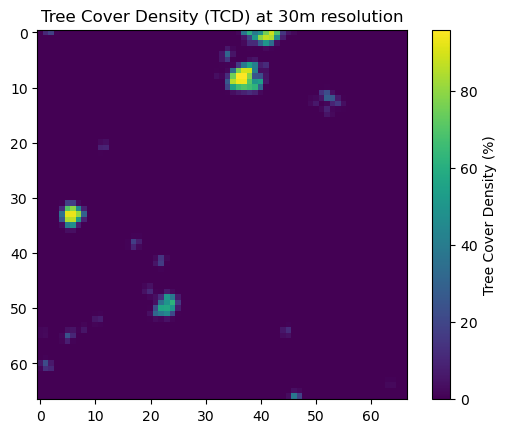

IMP30m metadata:
{'driver': 'GTiff', 'dtype': 'float32', 'nodata': nan, 'width': 67, 'height': 67, 'count': 1, 'crs': CRS.from_wkt('PROJCS["RGF93 v1 / Lambert-93",GEOGCS["RGF93 v1",DATUM["Reseau_Geodesique_Francais_1993_v1",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6171"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4171"]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",46.5],PARAMETER["central_meridian",3],PARAMETER["standard_parallel_1",49],PARAMETER["standard_parallel_2",44],PARAMETER["false_easting",700000],PARAMETER["false_northing",6600000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","2154"]]'), 'transform': Affine(30.0, 0.0, 460000.24999773875,
       0.0, -30.0, 6905999.749998286)}


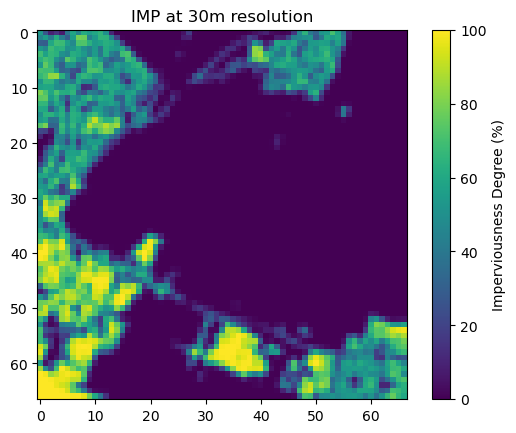

In [8]:
# ##### CLMS HRL TCF #####
# CLMS_HRLVLCC_TCD_S2023_R100m_E35N29_03035_V01_R00 stands for:
# Copernicus Land Monitoring Service – High-Resolution Layer, Vegetation & Land-Cover Characteristics; Tree Cover Density, single year 2023, 100-m resolution, tile at 35°E 29°N, product version 1, revision 0.
TCD_request = {
    "dataset_id": "EO:EEA:DAT:HRL:TCF", # Tree Cover Fraction, 
    "bbox": bbox_wgs84,
}

TCD_matches = hda_client.search(TCD_request)

# See all available products
# for item in TCF_matches.results:
#     loc = item["properties"]["location"]
#     print(loc)

TCD_best_results = filter_clms_products(TCD_matches, product_code="TCD", year=2020, resolution=10)
print("TCD best results:", TCD_best_results)

download_TCD_dir = os.path.join(area_dir, "TCD_original")
os.makedirs(download_TCD_dir, exist_ok=True)

TCD_path = download_and_extract(TCD_best_results, download_TCD_dir)
print("Downloaded TCD files:", TCD_path)

TCD_dst_path = os.path.join(bounding_box_dir, "TCD30m.tif")

reproject_to_match(TCD_path[0], TCD_dst_path, output_lidar30m_DSM, resampling=Resampling.bilinear)


# ##### CLMS HRL IMP #####
IMP_request = {
    "dataset_id": "EO:EEA:DAT:HRL:IMP", # Impervious Built-Up Area
    "bbox": bbox_wgs84,
}

IMP_matches = hda_client.search(IMP_request)

IMP_best_results = filter_clms_products(IMP_matches, product_code="IMD", year=2021, resolution=10) # Imperviousness Degree
print("IMP best results:", IMP_best_results)

download_IMP_dir = os.path.join(area_dir, "IMP_original")
os.makedirs(download_IMP_dir, exist_ok=True)

IMP_path = download_and_extract(IMP_best_results, download_IMP_dir)
print("Downloaded IMP files:", IMP_path)

IMP_dst_path = os.path.join(bounding_box_dir, "IMP30m.tif")

reproject_to_match(IMP_path[0], IMP_dst_path, output_lidar30m_DSM, resampling=Resampling.bilinear)

with rasterio.open(TCD_dst_path) as src:
    print("TCD30m metadata:")
    print(src.meta) 
    plt.imshow(src.read(1), cmap='viridis')
    plt.colorbar(label='Tree Cover Density (%)')
    plt.title('Tree Cover Density (TCD) at 30m resolution')
    plt.show()

with rasterio.open(IMP_dst_path) as src:
    print("IMP30m metadata:")
    print(src.meta) 
    plt.imshow(src.read(1), cmap='viridis')
    plt.colorbar(label='Imperviousness Degree (%)')
    plt.title('IMP at 30m resolution')
    plt.show()

* We can visualize all the titles we downloaded

* Recombine them to obtain the expected ROI 
* Save the result in lidar_output_dir
* Visualize it

### Download Copernicus data
* DSM 30m resolution
* Available everywhere in the world
* Just need the bounding box (no need to recombine tiles)

In [9]:
cop_dir = os.path.join(area_dir, "COP30m")
os.makedirs(cop_dir, exist_ok=True)

cop_path = os.path.join(cop_dir, f"cop_dem30m_original.tif")
download_cop_dem(bbox_wgs84, api_key, cop_path)

cop_dst_path = os.path.join(bounding_box_dir, "COP30m.tif")

reproject_to_match(
    cop_path,
    cop_dst_path,
    output_lidar30m_DSM,
    resampling=Resampling.bilinear
)

print_lidar_metadata(output_lidar30m_DSM)

# Get bounds (xmin, ymin, xmax, ymax)
with rasterio.open(cop_dst_path) as src:
    cop30m_DSM = src.read(1)
    bounds = src.bounds
    extent = (bounds.left, bounds.right, bounds.bottom, bounds.top)    

    transform = src.transform  # affine transform
    pixel_width  = transform.a
    pixel_height = abs(transform.e)
    print("Pixel resolution COP DEM:", pixel_width, "x", pixel_height, "meters")

# Get bounds (xmin, ymin, xmax, ymax)
with rasterio.open(output_lidar30m_DSM) as src:
    cop30m_DSM = src.read(1)

    bounds = src.bounds
    extent = (bounds.left, bounds.right, bounds.bottom, bounds.top)    

    transform = src.transform  # affine transform
    pixel_width  = transform.a
    pixel_height = abs(transform.e)
    print("Pixel resolution COP DEM:", pixel_width, "x", pixel_height, "meters")

Request: https://portal.opentopography.org/API/globaldem?demtype=COP30&south=49.19068925139526&north=49.209396035978884&west=-0.29298392937540874&east=-0.2667218084979135&outputFormat=GTiff&API_Key=38b3211483d503ddd81882f2259b6201


✅ Saved → /home/renauld/DSM/data_test_5/Caen/COP30m/cop_dem30m_original.tif
Reprojected raster saved to: /home/renauld/DSM/data_test_5/Caen/X-460000.5_X+461999.5_Y-6904000.25_Y+6905999.75/COP30m.tif

===== TILE: /home/renauld/DSM/data_test_5/Caen/X-460000.5_X+461999.5_Y-6904000.25_Y+6905999.75/Lidar30m_DSM.tif =====

--- BASIC INFO ---
CRS: EPSG:2154
Bounds: BoundingBox(left=460000.24999773875, bottom=6903989.749998286, right=462010.24999773875, top=6905999.749998286)
Resolution: (30.0, 30.0)
Width x Height: 67 x 67

--- RASTER METADATA ---
driver: GTiff
dtype: float32
nodata: -9999.0
width: 67
height: 67
count: 1
crs: EPSG:2154
transform: | 30.00, 0.00, 460000.25|
| 0.00,-30.00, 6905999.75|
| 0.00, 0.00, 1.00|

--- TIFF TAGS ---
AREA_OR_POINT: Area

--- BAND TAGS ---
Pixel resolution COP DEM: 30.0 x 30.0 meters
Pixel resolution COP DEM: 30.0 x 30.0 meters


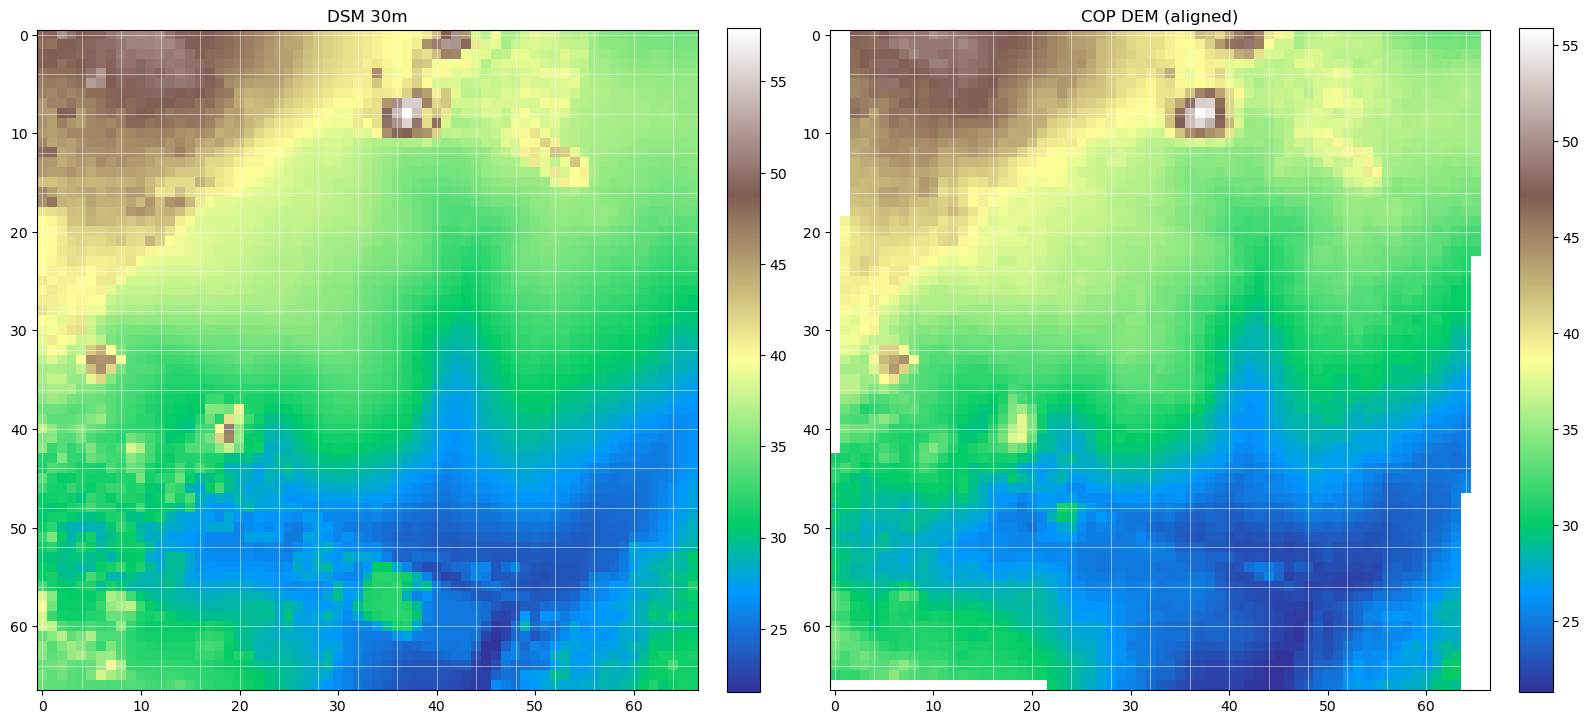

In [ ]:
# Open rasters

with rasterio.open(output_lidar30m_DSM) as lidar_30m, rasterio.open(cop_dst_path) as cop:
    lidar_30m_arr = lidar_30m.read(1)
    cop_arr = cop.read(1)

# Parameters
grid_step = 4  # draw a grid line every 4 pixels

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Function to add grid lines
def add_grid(ax, shape, step):
    for x in range(0, shape[1], step):
        ax.axvline(x, color='white', linewidth=0.5, alpha=0.7)
    for y in range(0, shape[0], step):
        ax.axhline(y, color='white', linewidth=0.5, alpha=0.7)

# Left: DSM
im1 = axes[0].imshow(lidar_30m, cmap="terrain")
add_grid(axes[0], lidar_30m.shape, grid_step)
axes[0].set_title("DSM 30m")

# Right: COP DEM
im2 = axes[1].imshow(cop_arr, cmap="terrain")
add_grid(axes[1], cop_arr.shape, grid_step)
axes[1].set_title("COP DEM (aligned)")

# Colorbars
fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)
fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

### Download contexly image

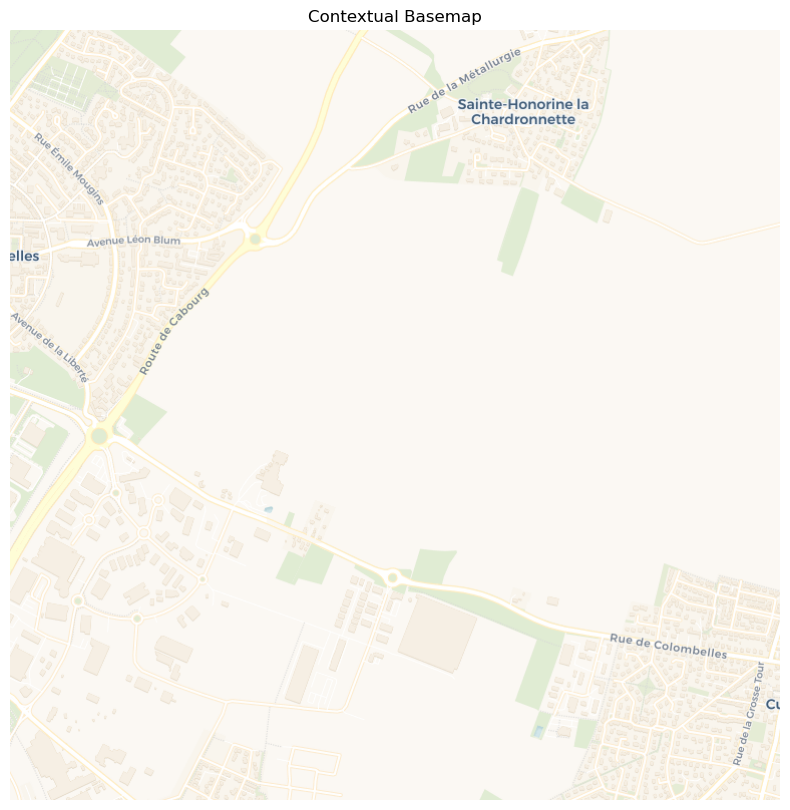

In [11]:
cx_image = download_contextly_image(bbox_wgs84)

plt.figure(figsize=(10, 10))
plt.imshow(cx_image)
plt.title("Contextual Basemap")
plt.axis('off')
plt.show()


### Find a single Sentinel-2 granule (one every 2-3 days between A and B)
* Download it
* Check if the cloud cover if acceptable

In [ ]:
startDate = "2020-08-04T00:00:00.000Z"
completionDate = "2020-08-06T00:00:00.000Z"
startDayDate = startDate.split("T")[0]
print(startDayDate)

# Your JSON file:
S2_request = {
    "dataset_id": "EO:ESA:DAT:SENTINEL-2",
    "bbox": bbox_wgs84,
    "startDate": startDate,
    "completionDate": completionDate,
    "processingLevel": "S2MSI2A"
}

# S2_matches = hda_client.search(S2_request)
# print("S2 matches:")
# print(S2_matches)

# if len(S2_matches.results) != 1:
#     raise ValueError("Not exactly 1 dataset found")

S2_dir = os.path.join(area_dir, "S2_original", startDayDate)
tmp_dir = os.path.join(area_dir, "tmp_downloads")

# S2_path = download_and_extract(S2_matches, S2_dir, tmp_dir)

# Find the single folder inside S2_dir
subfolders = [f.path for f in os.scandir(S2_dir) if f.is_dir()]
if len(subfolders) != 1:
    raise RuntimeError(f"Expected exactly one folder inside {S2_dir}, found {len(subfolders)}")

S2_subdir = subfolders[0]

# Now pass the subfolder to your function
S2_metadata = read_s2_full_quality_metadata(S2_subdir)
for k, v in S2_metadata.items():
    print(f"{k}: {v}\n")

print(is_granule_usable(S2_metadata, cloud_thresh=5.0))  # -> False

# S2_path = os.path.join(cop_dir, f"cop_dem30m_original.tif")
# download_cop_dem(bbox_wgs84, api_key, cop_path)

# cop_dst_path = os.path.join(bounding_box_dir, "COP30m.tif")

# reproject_to_match(
#     cop_path,
#     cop_dst_path,
#     output_lidar30m_DSM,
#     resampling=Resampling.bilinear
# )

# SAFE_dir = S2_dir.next()


2020-08-04
Cloud_Coverage_Assessment: 10.657652

CLOUDY_PIXEL_OVER_LAND_PERCENTAGE: 13.437639

CLOUD_SHADOW_PERCENTAGE: 6.0757200000000005

THIN_CIRRUS_PERCENTAGE: 1.440002

MEDIUM_PROBA_CLOUDS_PERCENTAGE: 5.059588

HIGH_PROBA_CLOUDS_PERCENTAGE: 4.158062

NODATA_PIXEL_PERCENTAGE: 0.0

SATURATED_DEFECTIVE_PIXEL_PERCENTAGE: 0.0

DARK_FEATURES_PERCENTAGE: 0.019028

VEGETATION_PERCENTAGE: 43.790808000000006

NOT_VEGETATED_PERCENTAGE: 15.716428

WATER_PERCENTAGE: 23.489766000000003

UNCLASSIFIED_PERCENTAGE: 0.2506

SENSING_TIME: None

TILE_ID: None

False


### Reproject all the band on the boundary box

In [82]:
granule_dir = os.path.join(S2_subdir, "GRANULE")
first_granule = list(os.scandir(granule_dir))[0]

R10m_dir = os.path.join(first_granule.path, "IMG_DATA", "R10m")
print(R10m_dir)

bands_dir = os.path.join(bounding_box_dir, "S2_bands")
os.makedirs(bands_dir, exist_ok=True)

for file in os.scandir(R10m_dir):
    print(file.path)

    band_name = file.name.split("_")[2]
    res = file.name.split("_")[3].split(".")[0]
    # print(res)
    dst_path = os.path.join(bands_dir, f"{band_name}_{res}.tif")
    print(dst_path)
    reproject_to_match(
        file.path,
        dst_path,
        output_lidar30m_DSM,
        resampling=Resampling.bilinear
    )


/home/renauld/DSM/data_test_5/Caen/S2_original/2020-08-04/S2A_MSIL2A_20200804T110631_N0500_R137_T30UXV_20230316T164108.SAFE/GRANULE/L2A_T30UXV_A026732_20200804T111447/IMG_DATA/R10m
/home/renauld/DSM/data_test_5/Caen/S2_original/2020-08-04/S2A_MSIL2A_20200804T110631_N0500_R137_T30UXV_20230316T164108.SAFE/GRANULE/L2A_T30UXV_A026732_20200804T111447/IMG_DATA/R10m/T30UXV_20200804T110631_B03_10m.jp2
/home/renauld/DSM/data_test_5/Caen/X-460000.5_X+461999.5_Y-6904000.25_Y+6905999.75/S2_bands/B03_10m.tif
Reprojected raster saved to: /home/renauld/DSM/data_test_5/Caen/X-460000.5_X+461999.5_Y-6904000.25_Y+6905999.75/S2_bands/B03_10m.tif
/home/renauld/DSM/data_test_5/Caen/S2_original/2020-08-04/S2A_MSIL2A_20200804T110631_N0500_R137_T30UXV_20230316T164108.SAFE/GRANULE/L2A_T30UXV_A026732_20200804T111447/IMG_DATA/R10m/T30UXV_20200804T110631_B08_10m.jp2
/home/renauld/DSM/data_test_5/Caen/X-460000.5_X+461999.5_Y-6904000.25_Y+6905999.75/S2_bands/B08_10m.tif
Reprojected raster saved to: /home/renauld/DSM

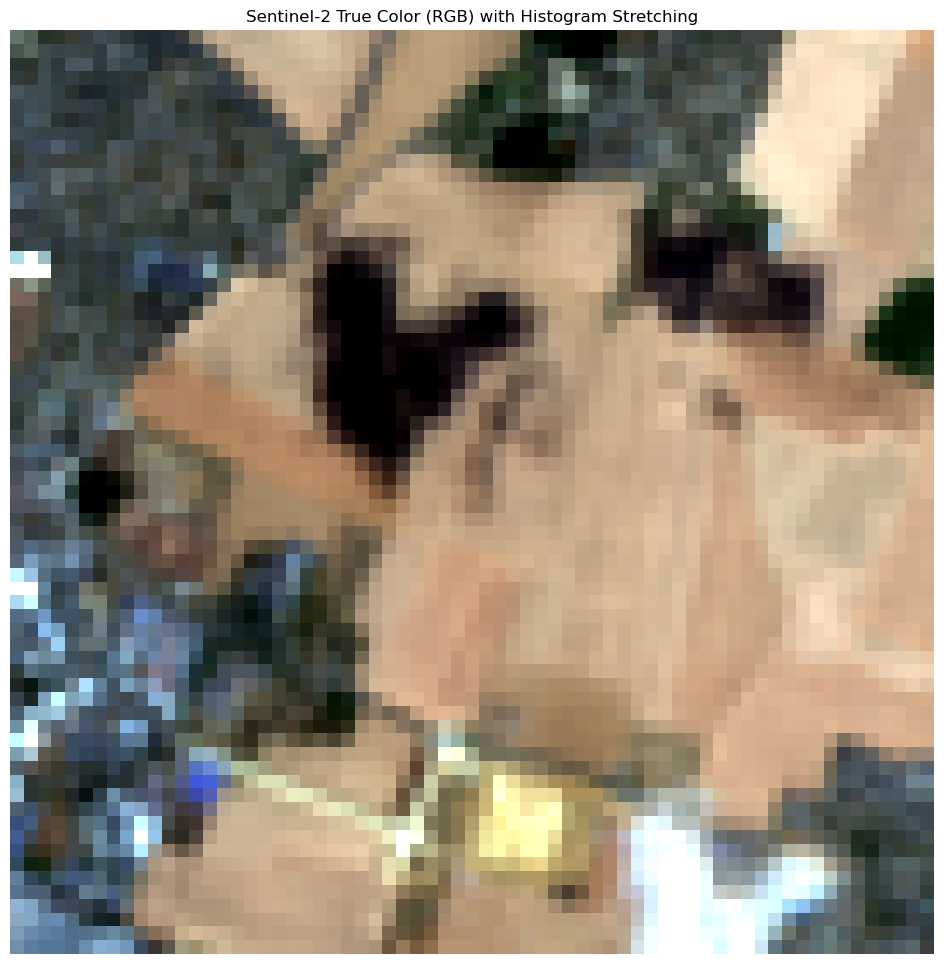

In [122]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import os

# folder = "/home/renauld/DSM/data_test_5/Caen/S2_original/2020-08-04/S2A_MSIL2A_20200804T110631_N0500_R137_T30UXV_20230316T164108.SAFE/GRANULE/L2A_T30UXV_A026732_20200804T111447/IMG_DATA/R20m/"

# bands_files = {
# "R": "T30UXV_20200804T110631_B04_20m.jp2",
# "G": "T30UXV_20200804T110631_B03_20m.jp2",
# "B": "T30UXV_20200804T110631_B02_20m.jp2"
# }

folder = "/home/renauld/DSM/data_test_5/Caen/X-460000.5_X+461999.5_Y-6904000.25_Y+6905999.75/S2_bands"

bands_files = {
"R": "B04_10m.tif",
"G": "B03_10m.tif",
"B": "B02_10m.tif"
}

bands = []
for color in ["R","G","B"]:
    with rasterio.open(os.path.join(folder, bands_files[color])) as src:
        band = src.read(1).astype(float)
        # clip extreme values for better visualization
        band = np.clip(band, 0, 10000)
        bands.append(band)

        if color == "R":
            meta = src.meta.copy()

rgb = np.stack(bands, axis=-1)

rgb_stretched = np.stack([stretch(rgb[:,:,i]) for i in range(3)], axis=-1)

plt.figure(figsize=(12,12))
plt.imshow(rgb_stretched)
plt.axis('off')
plt.title("Sentinel-2 True Color (RGB) with Histogram Stretching")
plt.show()

# Save RBG image
rgb_uint8 = (rgb_stretched * 255).astype(np.uint8)
meta.update({
    "count": 3,
    "dtype": "uint8",
    "nodata": 0
})

rgb_path = os.path.join(folder, "RBG_30m.tif")

with rasterio.open(rgb_path, "w", **meta) as dst:
    for i in range(3):
        dst.write(rgb_uint8[:,:,i], i+1)

### Visualize the data
* Download a contextly image
* Plot the 3 images together (will and without equal max)

66.11053
(67, 67)


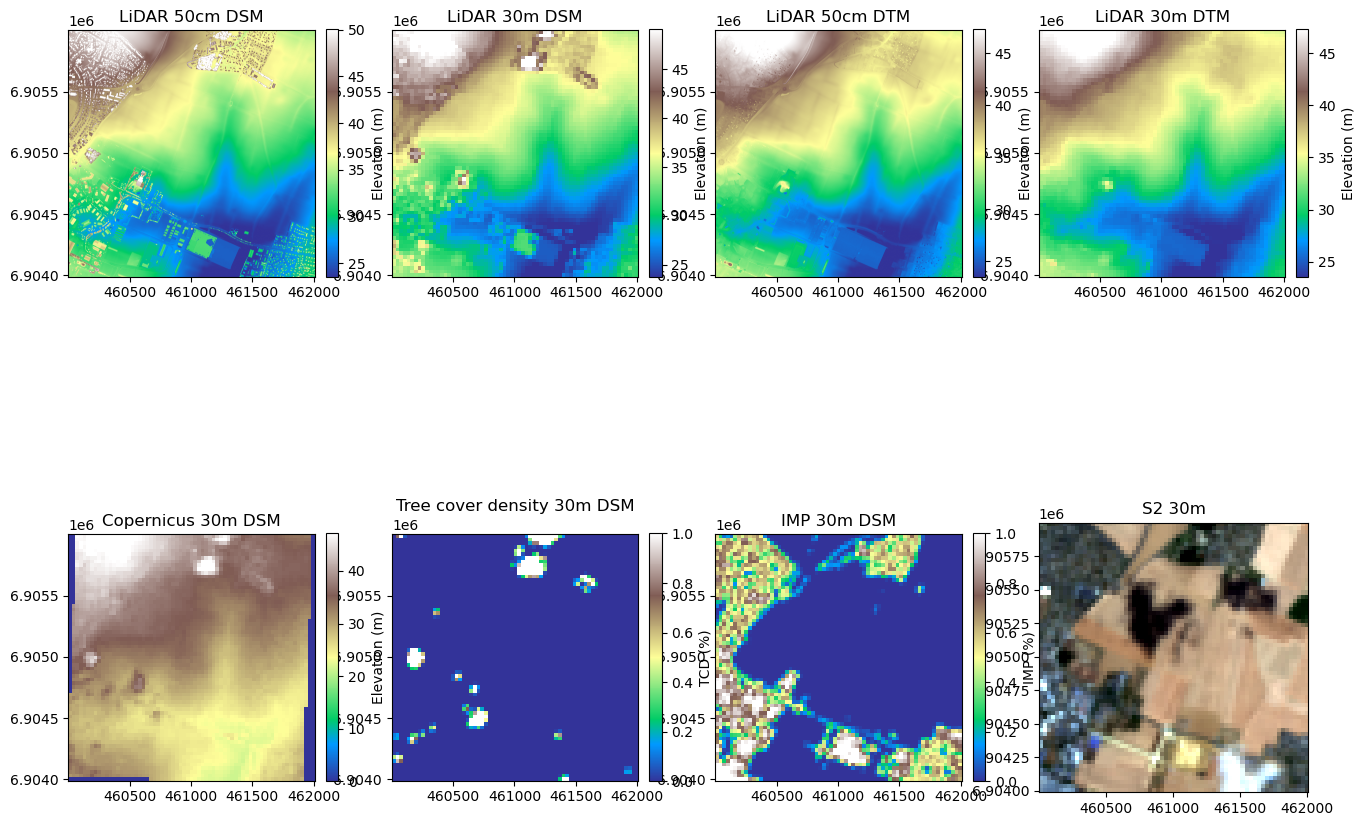

In [136]:
vmin = -5  
# vmax = clipped_lidar50cm_DSM.max()

fig, ax = plt.subplots(2, 4, figsize=(16, 12))

with rasterio.open(output_lidar50cm_DSM) as src:
    img = src.read(1)

    im0 = ax[0,0].imshow(
            clip_extremes(img),
            cmap="terrain",
            extent=extent,      # <-- HERE
            origin="upper", 
        )
    ax[0,0].set_title("LiDAR 50cm DSM")
    fig.colorbar(im0, ax=ax[0,0], label="Elevation (m)", fraction=0.046, pad=0.04, shrink=0.6)

    print(img.max())

with rasterio.open(output_lidar30m_DSM) as src:
    img = src.read(1)
    im0 = ax[0,1].imshow(
            clip_extremes(img),
            cmap="terrain",
            extent=extent,      # <-- HERE
            origin="upper", 
            # vmin = vmin, 
            # vmax = vmax
        )
    ax[0,1].set_title("LiDAR 30m DSM")
    fig.colorbar(im0, ax=ax[0,1], label="Elevation (m)", fraction=0.046, pad=0.04, shrink=0.6)

with rasterio.open(output_lidar50cm_DTM) as src:
    img = src.read(1)
    im0 = ax[0,2].imshow(
            clip_extremes(img),
            cmap="terrain",
            extent=extent,      # <-- HERE
            origin="upper", 
            # vmin = vmin, 
            # vmax = vmax
        )
    ax[0,2].set_title("LiDAR 50cm DTM")
    fig.colorbar(im0, ax=ax[0,2], label="Elevation (m)", fraction=0.046, pad=0.04, shrink=0.6)

with rasterio.open(output_lidar30m_DTM) as src:
    img = src.read(1)
    im0 = ax[0,3].imshow(
            clip_extremes(img),
            cmap="terrain",
            extent=extent,      # <-- HERE
            origin="upper", 
            # vmin = vmin, 
            # vmax = vmax
        )
    ax[0,3].set_title("LiDAR 30m DTM")
    fig.colorbar(im0, ax=ax[0,3], label="Elevation (m)", fraction=0.046, pad=0.04, shrink=0.6)


with rasterio.open(cop_dst_path) as src:
    img = src.read(1)
    img = np.nan_to_num(img, nan=0)
    im0 = ax[1,0].imshow(
            clip_extremes(img),
            cmap="terrain",
            extent=extent,      # <-- HERE
            origin="upper", 
            # vmin = vmin, 
            # vmax = vmax
        )
    ax[1,0].set_title("Copernicus 30m DSM")
    fig.colorbar(im0, ax=ax[1,0], label="Elevation (m)", fraction=0.046, pad=0.04, shrink=0.6)


with rasterio.open(TCD_dst_path) as src:
    img = src.read(1)
    im0 = ax[1,1].imshow(
            stretch(img),
            cmap="terrain",
            extent=extent,      # <-- HERE
            origin="upper", 
            # vmin = vmin, 
            # vmax = vmax
        )
    ax[1,1].set_title("Tree cover density 30m DSM")
    fig.colorbar(im0, ax=ax[1,1], label="TCD (%)", fraction=0.046, pad=0.04, shrink=0.6)


with rasterio.open(IMP_dst_path) as src:
    img = src.read(1)
    im0 = ax[1,2].imshow(
            stretch(img),
            cmap="terrain",
            extent=extent,      # <-- HERE
            origin="upper", 
            # vmin = vmin, 
            # vmax = vmax
        )
    ax[1,2].set_title("IMP 30m DSM")

    print(img.shape)
    fig.colorbar(im0, ax=ax[1,2], label="IMP (%)", fraction=0.046, pad=0.04, shrink=0.6)


with rasterio.open(rgb_path) as src:

    img = np.zeros((src.height, src.width, 3), dtype=np.uint8)

    img[:,:,0] = src.read(1)
    img[:,:,1] = src.read(2)
    img[:,:,2] = src.read(3)

    im0 = ax[1,3].imshow(
            img,
            cmap="terrain",
            extent=extent,      # <-- HERE
            origin="upper", 
            # vmin = vmin, 
            # vmax = vmax
        )
    ax[1,3].set_title("S2 30m")
    # fig.colorbar(im0, ax=ax[1,3], label="Elevation (m)")

plt.show()

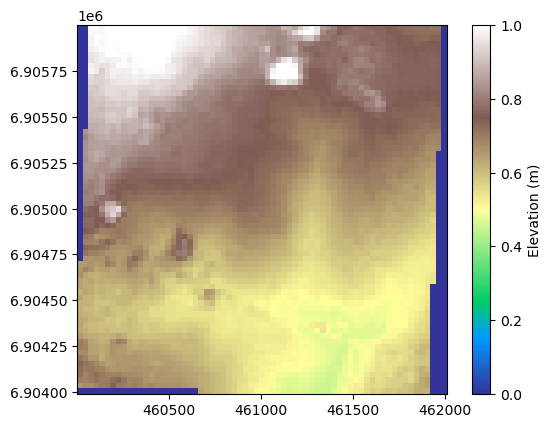

In [112]:
with rasterio.open(cop_dst_path) as src:
    img = src.read(1)
    # Mask NaNs
    # Replace NaNs with a value (e.g., 0 or min value)
    img_plot = np.nan_to_num(img, nan=0)  # replace NaN by 0
    plt.imshow(stretch(img_plot), cmap="terrain", extent=extent, origin="upper")
    plt.colorbar(label="Elevation (m)")
    plt.show()


In [ ]:
# List all datasets (no limit) available from the HDA API
datasets = hda_client.datasets(limit=None)

# Filter datasets related to Sentinel-2
sentinel2_datasets = [ds for ds in datasets if 'sentinel-2' in ds.get('dataset_id', '').lower() or 'S2' in ds.get('title', '')]

print(f"Found {len(sentinel2_datasets)} Sentinel-2 related datasets")

# Print basic information for each Sentinel-2 dataset
for ds in sentinel2_datasets:
    print(f"ID: {ds.get('dataset_id')}")
    print(f"Title: {ds.get('title')}")
    print(f"Processing level / Abstract: {ds.get('metadata', {}).get('abstract')}")
    print(f"Available formats: {ds.get('metadata', {}).get('availableFormats')}")
    print(f"DOI / URL: {ds.get('metadata', {}).get('digitalTransfers', [{}])[0].get('availability', {}).get('url')}")
    print('---')

# You can further refine filtering using keywords, processing levels, or date ranges if needed


Found 1 Sentinel-2 related datasets
ID: EO:ESA:DAT:SENTINEL-2
Title: None
Processing level / Abstract: The Sentinel-2 mission is a land monitoring constellation of two satellites that provide high resolution optical imagery and provide continuity for the current SPOT and Landsat missions. The mission provides a global coverage of the Earth's land surface every 10 days with one satellite and 5 days with 2 satellites, making the data of great use in on-going studies. The satellites are equipped with the state-of-the-art MSI (Multispectral Imager) instrument, that offers high-resolution optical imagery. Products are a compilation of elementary granules of fixed size, within a single orbit. A granule is the minimum indivisible partition of a product (containing all possible spectral bands).
For Level-1C and Level-2A, the granules, also called tiles, are 100x100km2 ortho-images in UTM/WGS84 projection. The UTM (Universal Transverse Mercator) system divides the Earth's surface into 60 zones.

In [ ]:
import rasterio
import matplotlib.pyplot as plt

with rasterio.open("T32TNN_20170802T101031_AOT_20m.jp2") as src:
    arr = src.read(1)               # read band
    transform = src.transform       # affine
    crs = src.crs                   # CRS object
    nodata = src.nodata
    profile = src.profile           # full metadata

    print("NoData value:", nodata)
    print("Profile:", profile)
    print("Transform:", transform)
    print("CRS:", crs)

    plt.imshow(arr, cmap='gray')
    plt.colorbar()
    plt.title("AOT Band")
    plt.show()


print(arr.shape, crs)